In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from matplotlib.lines import Line2D

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

try:
    from google.colab import files as colab_files
    uploaded = colab_files.upload()

    if uploaded:
        csv_path = list(uploaded.keys())[0]
    else:
        csv_path = "all_5_crops_combined.csv"

except Exception:
    csv_path = "all_5_crops_combined.csv"


# Read CSV
raw = pd.read_csv(csv_path)

# Rename columns
raw = raw.rename(columns={
    "Farm_ID": "Farm",
    "Sentinel_Date": "Date",
    "crop label": "Crop" # Renaming 'crop label' to 'Crop'
})

# Convert date
raw["Date"] = pd.to_datetime(raw["Date"], format="%d-%m-%Y")

# Keep only required columns
raw = raw[["Farm", "Crop", "Date", "NDVI"]]

# Average NDVI if duplicate observations exist
raw = (
    raw.groupby(["Farm", "Crop", "Date"], as_index=False)["NDVI"]
    .mean()
)

# Remove invalid NDVI values
raw = raw[raw["NDVI"] >= 0].reset_index(drop=True)

# Sort
df = raw.sort_values(["Crop", "Farm", "Date"]).reset_index(drop=True)

# Final dataframe
ndvi_df = df.copy()

# Summary
print("Loaded:", df.shape)
print("Crops:", df["Crop"].unique())
print("Total farms:", df["Farm"].nunique())
print("Date range:", df["Date"].min().date(), "→", df["Date"].max().date())
print("NDVI range:", round(df["NDVI"].min(), 3), "→", round(df["NDVI"].max(), 3))
print()
print(df.groupby("Crop")["Farm"].nunique().rename("n_farms"))

Loaded: (6022, 4)
Crops: ['Cotton' 'Onion' 'Paddy' 'Sugarcane']
Total farms: 148
Date range: 2021-01-03 → 2026-03-07
NDVI range: 0.001 → 0.932

Crop
Cotton       23
Onion        50
Paddy        25
Sugarcane    50
Name: n_farms, dtype: int64


In [ ]:
CROP_CONFIG = {
    'Gram':        {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Lentil':      {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Maize':       {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Mustard':     {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Potato':      {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Rice':        {'smooth': 4, 'max_cycles': 1, 'search_months': 5, 'use_prominence': False, 'prominence': None},
    'Wheat':       {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Sugarcane':   {'smooth': 6, 'max_cycles': 1, 'search_months': 8, 'use_prominence': True,  'prominence': 0.08},
    'Banana':      {'smooth': 6, 'max_cycles': 1, 'search_months': 7, 'use_prominence': True,  'prominence': 0.06},
    'Grapes':      {'smooth': 3, 'max_cycles': 2, 'search_months': 3, 'use_prominence': True,  'prominence': 0.10},
    'Onion':       {'smooth': 2, 'max_cycles': 1, 'search_months': 3, 'use_prominence': False, 'prominence': None},
    'Tomato':      {'smooth': 3, 'max_cycles': 3, 'search_months': 2, 'use_prominence': False, 'prominence': None},
    'Paddy':       {'smooth': 3, 'max_cycles': 2, 'search_months': 3, 'use_prominence': True,  'prominence': 0.15},
    'Soybean':     {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Cotton':      {'smooth': 2, 'max_cycles': 2, 'search_months': 4, 'use_prominence': True,  'prominence': 0.07},
    'Jowar':       {'smooth': 4, 'max_cycles': 2, 'search_months': 4, 'use_prominence': False, 'prominence': None},
    'Bajra':       {'smooth': 3, 'max_cycles': 1, 'search_months': 3, 'use_prominence': False, 'prominence': None},
    'Tur':         {'smooth': 5, 'max_cycles': 1, 'search_months': 6, 'use_prominence': False, 'prominence': None},
    'Turmeric':    {'smooth': 6, 'max_cycles': 1, 'search_months': 8, 'use_prominence': True,  'prominence': 0.06},
    'Pomegranate': {'smooth': 6, 'max_cycles': 2, 'search_months': 4, 'use_prominence': True,  'prominence': 0.07},
    'Safflower':   {'smooth': 3, 'max_cycles': 2, 'search_months': 3, 'use_prominence': True,  'prominence': 0.08},
    'Cabbage':     {'smooth': 3, 'max_cycles': 3, 'search_months': 2, 'use_prominence': False, 'prominence': None}
}

DEFAULT_CFG = {'smooth': 4, 'max_cycles': 1, 'search_months': 4, 'use_prominence': False, 'prominence': None}

print('Total crops configured:', len(CROP_CONFIG))
print([c for c in CROP_CONFIG if c in df['Crop'].unique()], '← active for this dataset')

Total crops configured: 22
['Sugarcane', 'Onion', 'Paddy', 'Cotton'] ← active for this dataset


## 3. Detection Functions

In [ ]:
def split_into_years(dates):
    start = dates.min()
    end   = dates.max()
    segments = []
    seg_start = start
    while seg_start <= end:
        seg_end = seg_start + pd.DateOffset(years=1)
        segments.append((seg_start, seg_end))
        seg_start = seg_end
    return segments


def detect_cycles(dates, ndvi, cfg):
    s = pd.Series(ndvi).rolling(cfg['smooth'], center=True, min_periods=1).mean().values
    max_cycles = cfg['max_cycles']
    min_dist = max(3, len(s) // (max_cycles * 3))

    if cfg['use_prominence']:
        peaks, _ = find_peaks(s, prominence=cfg['prominence'], distance=min_dist)
    else:
        peaks, _ = find_peaks(s, height=0.3, distance=min_dist)

    if len(peaks) == 0:
        return [], s

    if len(peaks) > max_cycles:
        top_idx = np.argsort(s[peaks])[-max_cycles:]
        peaks = np.sort(peaks[top_idx])

    search_window = pd.DateOffset(months=cfg['search_months'])
    cycles = []
    for p in peaks:
        peak_date = dates[p]

        before_mask = (dates >= peak_date - search_window) & (dates <= peak_date)
        before_idx  = np.where(before_mask)[0]
        sowing = before_idx[np.argmin(s[before_idx])] if len(before_idx) > 0 else 0

        after_mask = (dates >= peak_date) & (dates <= peak_date + search_window)
        after_idx  = np.where(after_mask)[0]
        harvest = after_idx[np.argmin(s[after_idx])] if len(after_idx) > 0 else len(s) - 1

        cycles.append({'sowing': sowing, 'peak': p, 'harvest': harvest})

    return cycles, s


## 4. Run Detection on All Farms

In [ ]:
results_by_farm = {}

for crop in df['Crop'].unique():
    cfg = CROP_CONFIG.get(crop, DEFAULT_CFG)
    for farm, grp in df[df['Crop'] == crop].groupby('Farm'):
        grp = grp.reset_index(drop=True)
        dates = pd.to_datetime(grp['Date'].values.astype('datetime64[ns]'))
        ndvi  = grp['NDVI'].values

        segments = split_into_years(dates)
        smoothed_full = np.full(len(dates), np.nan)
        all_cycles = []

        for seg_idx, (seg_start, seg_end) in enumerate(segments):
            mask = (dates >= seg_start) & (dates < seg_end)
            seg_idx_arr = np.where(mask)[0]
            if len(seg_idx_arr) < 5:
                continue
            cycles, smoothed_seg = detect_cycles(dates[seg_idx_arr], ndvi[seg_idx_arr], cfg)
            smoothed_full[seg_idx_arr] = smoothed_seg
            for c in cycles:
                all_cycles.append({
                    'sowing':  seg_idx_arr[c['sowing']],
                    'peak':    seg_idx_arr[c['peak']],
                    'harvest': seg_idx_arr[c['harvest']],
                    'seg_idx': seg_idx,
                })

        results_by_farm[(crop, farm)] = {
            'dates': dates, 'ndvi': ndvi, 'smoothed': smoothed_full,
            'segments': segments, 'cycles': all_cycles,
        }

print(f'Processed {len(results_by_farm)} (crop, farm) combinations')


Processed 148 (crop, farm) combinations


## 5. Plot

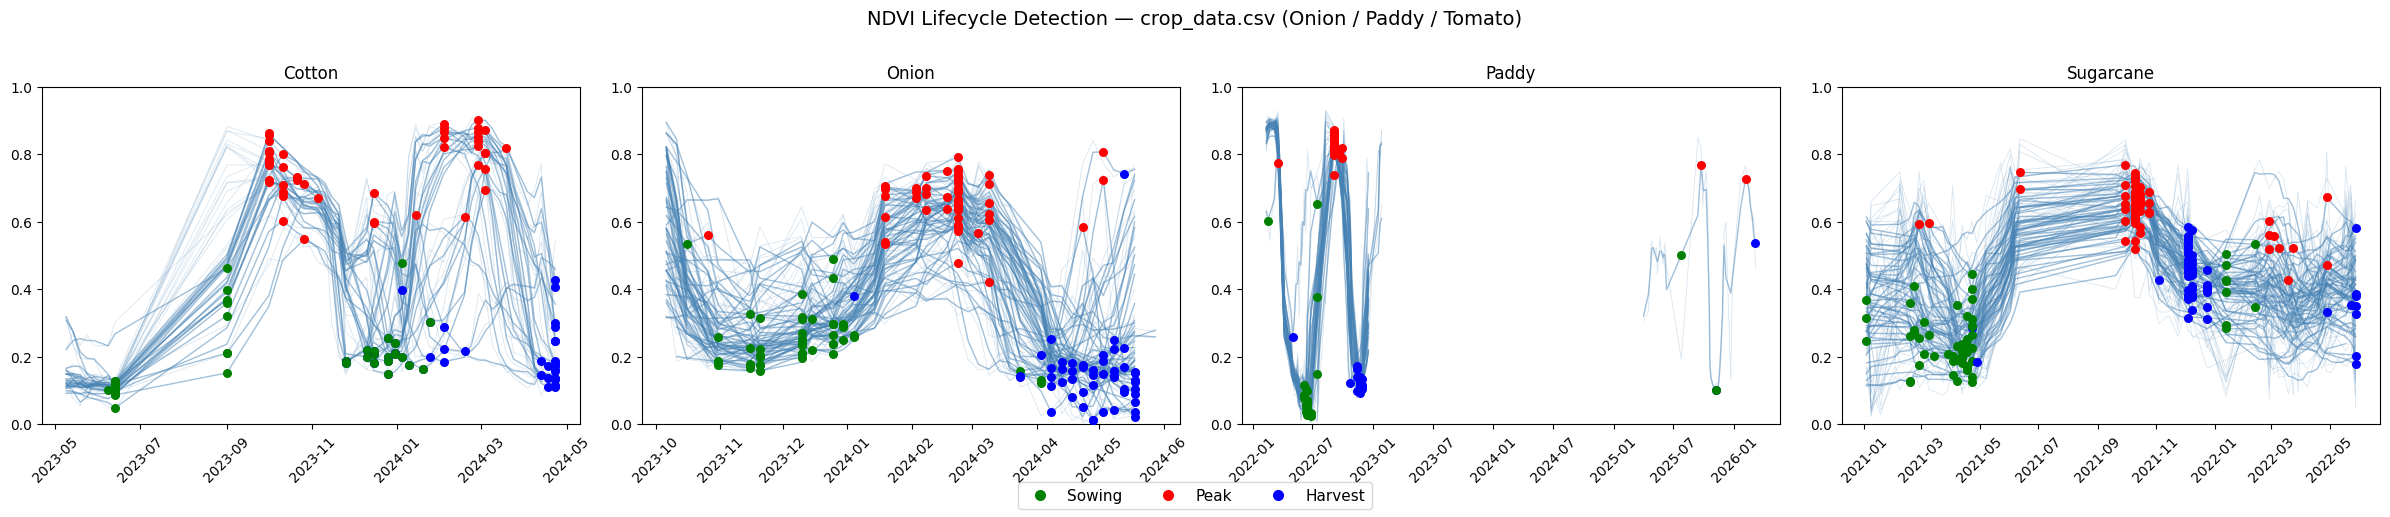

In [ ]:
crops = df['Crop'].unique()
ncols = min(4, len(crops))
nrows = int(np.ceil(len(crops) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
axes = axes.flatten()

for i, crop in enumerate(crops):
    ax = axes[i]
    for farm in df[df['Crop'] == crop]['Farm'].unique():
        r = results_by_farm[(crop, farm)]
        ax.plot(r['dates'], r['ndvi'], linewidth=0.6, alpha=0.2, color='steelblue')
        ax.plot(r['dates'], r['smoothed'], linewidth=1.0, alpha=0.5, color='steelblue')
        for c in r['cycles']:
            ax.scatter(r['dates'][c['sowing']],  r['smoothed'][c['sowing']],  color='green', s=30, zorder=5)
            ax.scatter(r['dates'][c['peak']],    r['smoothed'][c['peak']],    color='red',   s=30, zorder=5)
            ax.scatter(r['dates'][c['harvest']], r['smoothed'][c['harvest']], color='blue',  s=30, zorder=5)
    ax.set_title(crop, fontsize=12)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=9, label='Sowing'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',   markersize=9, label='Peak'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',  markersize=9, label='Harvest'),
]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=11)
plt.suptitle('NDVI Lifecycle Detection — crop_data.csv (Onion / Paddy / Tomato)', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


## 6. Build Lifecycle Results Table

In [ ]:
_trapz = getattr(np, 'trapezoid', None) or np.trapz

records = []

for (crop, farm), r in results_by_farm.items():
    dates, ndvi, smoothed = r['dates'], r['ndvi'], r['smoothed']
    seg_counters = {}
    for c in sorted(r['cycles'], key=lambda x: x['peak']):
        seg_counters[c['seg_idx']] = seg_counters.get(c['seg_idx'], 0) + 1
        cycle_num = seg_counters[c['seg_idx']]

        sow_date  = pd.Timestamp(dates[c['sowing']])
        peak_date = pd.Timestamp(dates[c['peak']])
        harv_date = pd.Timestamp(dates[c['harvest']])

        mask = (dates >= sow_date) & (dates <= harv_date)
        seg_days = pd.to_timedelta(dates[mask] - sow_date).days.astype(float)
        seg_ndvi = ndvi[mask]
        auc = float(_trapz(seg_ndvi, seg_days)) if len(seg_days) > 1 else np.nan
        mean_ndvi = float(np.nanmean(seg_ndvi))

        records.append({
            'Crop':          crop,
            'Farm':          farm,
            'Year_Segment':  c['seg_idx'] + 1,
            'Cycle':         cycle_num,
            'Sowing_Date':   sow_date,
            'Sowing_Month':  sow_date.month,
            'Sowing_NDVI':   round(float(smoothed[c['sowing']]), 4),
            'Peak_Date':     peak_date,
            'Peak_Month':    peak_date.month,
            'Peak_NDVI':     round(float(smoothed[c['peak']]),    4),
            'Harvest_Date':  harv_date,
            'Harvest_Month': harv_date.month,
            'Harvest_NDVI':  round(float(smoothed[c['harvest']]), 4),
            'Duration_Days': (harv_date - sow_date).days,
            'AUC':           round(auc, 2) if not np.isnan(auc) else np.nan,
            'Mean_NDVI':     round(mean_ndvi, 4),
        })

lifecycle_df = pd.DataFrame(records)
lifecycle_df.to_excel('lifecycle_results.xlsx', index=False)
print(f'Total cycles detected: {len(lifecycle_df)}')
print(lifecycle_df.groupby('Crop').size().rename('cycles'))

Total cycles detected: 182
Crop
Cotton       46
Onion        50
Paddy        27
Sugarcane    59
Name: cycles, dtype: int64


In [ ]:
RULES = {
    'Onion':     {'sow_months': [5,6,7,8,9,10,11,12,1], 'harv_months': [1,2,3,4,5,10,11,12], 'min_dur': 85,  'max_dur': 180, 'min_drop': 0.2,  'min_rise': 0.15},
    'Tomato':    {'sow_months': list(range(1,13)),    'harv_months': list(range(1,13)),    'min_dur': 55,  'max_dur': 130, 'min_drop': 0.2,  'min_rise': 0.15},
    'Paddy':     {'sow_months': [5,6,7,8],            'harv_months': [9,10,11,12,1],      'min_dur': 90,  'max_dur': 180, 'min_drop': 0.2,  'min_rise': 0.15},
    'Sugarcane': {'sow_months': [1,2,3,4],            'harv_months': [10,11,12,1],        'min_dur': 180, 'max_dur': 365, 'min_drop': 0.12, 'min_rise': 0.12},
    'Cotton':    {'sow_months': [5,6,7,8,9], 'harv_months': [11,12,1,4],         'min_dur': 65,  'max_dur': 230, 'min_drop': 0.15, 'min_rise': 0.10}
}

def validate(row):
    rule = RULES.get(row['Crop'])
    if rule is None:
        return 'No rule defined'
    reasons = []
    if row['Sowing_Month'] not in rule['sow_months']:
        reasons.append(f"Sow month {row['Sowing_Month']} invalid")
    if row['Harvest_Month'] not in rule['harv_months']:
        reasons.append(f"Harvest month {row['Harvest_Month']} invalid")
    if not (rule['min_dur'] <= row['Duration_Days'] <= rule['max_dur']):
        reasons.append(f"Duration {row['Duration_Days']}d not in [{rule['min_dur']}-{rule['max_dur']}]")

    min_drop = rule.get('min_drop', 0.2)
    ndvi_drop = row['Peak_NDVI'] - row['Harvest_NDVI']
    if ndvi_drop <= min_drop:
        reasons.append(f"Peak-Harvest NDVI drop {ndvi_drop:.3f} <= {min_drop}")

    min_rise = rule.get('min_rise', 0.15)
    ndvi_rise = row['Peak_NDVI'] - row['Sowing_NDVI']
    if ndvi_rise <= min_rise:
        reasons.append(f"Peak-Sowing NDVI rise {ndvi_rise:.3f} <= {min_rise}")

    return 'Valid' if not reasons else '; '.join(reasons)

lifecycle_df['Validation'] = lifecycle_df.apply(validate, axis=1)
lifecycle_df['Is_Valid']   = lifecycle_df['Validation'] == 'Valid'

valid_df   = lifecycle_df[lifecycle_df['Is_Valid']].reset_index(drop=True)
invalid_df = lifecycle_df[~lifecycle_df['Is_Valid']].reset_index(drop=True)

print(f'Total: {len(lifecycle_df)}  |  Valid: {len(valid_df)}  |  Invalid: {len(invalid_df)}')
print(valid_df.groupby('Crop').size().rename('valid_cycles'))

valid_df.to_excel('lifecycle_results_validated.xlsx', index=False)
lifecycle_df.to_excel('lifecycle_results_with_flags.xlsx', index=False)

Total: 182  |  Valid: 135  |  Invalid: 47
Crop
Cotton       22
Onion        44
Paddy        25
Sugarcane    44
Name: valid_cycles, dtype: int64


## 8. Summary

In [ ]:
print('Multi-Crop Lifecycle Summary')
print(f'Total farms       : {df["Farm"].nunique()}')
print(f'Total dates       : {df["Date"].nunique()}')
print(f'Total rows (clean): {len(df)}')
print()
if len(lifecycle_df) > 0:
    print(f'Cycles detected  : {len(lifecycle_df)}')
    print(f'Valid cycles     : {len(valid_df)}')
    print(f'Invalid cycles   : {len(invalid_df)}')
    if len(valid_df) > 0:
        print()
        print('Valid cycle duration stats (days), by crop:')
        print(valid_df.groupby('Crop')['Duration_Days'].describe().round(1))
        print()
        print('Valid cycle peak NDVI stats, by crop:')
        print(valid_df.groupby('Crop')['Peak_NDVI'].describe().round(3))


Multi-Crop Lifecycle Summary
Total farms       : 148
Total dates       : 196
Total rows (clean): 6022

Cycles detected  : 182
Valid cycles     : 135
Invalid cycles   : 47

Valid cycle duration stats (days), by crop:
           count   mean   std    min    25%    50%    75%    max
Crop                                                            
Cotton      22.0  177.7  35.9  105.0  165.0  187.5  200.0  225.0
Onion       44.0  143.9  16.9  110.0  130.0  145.0  156.2  175.0
Paddy       25.0  153.4  15.4  105.0  150.0  160.0  165.0  170.0
Sugarcane   44.0  254.8  29.8  225.0  230.0  242.5  275.0  355.0

Valid cycle peak NDVI stats, by crop:
           count   mean    std    min    25%    50%    75%    max
Crop                                                             
Cotton      22.0  0.741  0.082  0.548  0.714  0.748  0.797  0.862
Onion       44.0  0.668  0.066  0.479  0.635  0.679  0.709  0.793
Paddy       25.0  0.826  0.030  0.740  0.812  0.830  0.839  0.872
Sugarcane   44.0  0.661  

## 9. Plot Valid Lifecycles



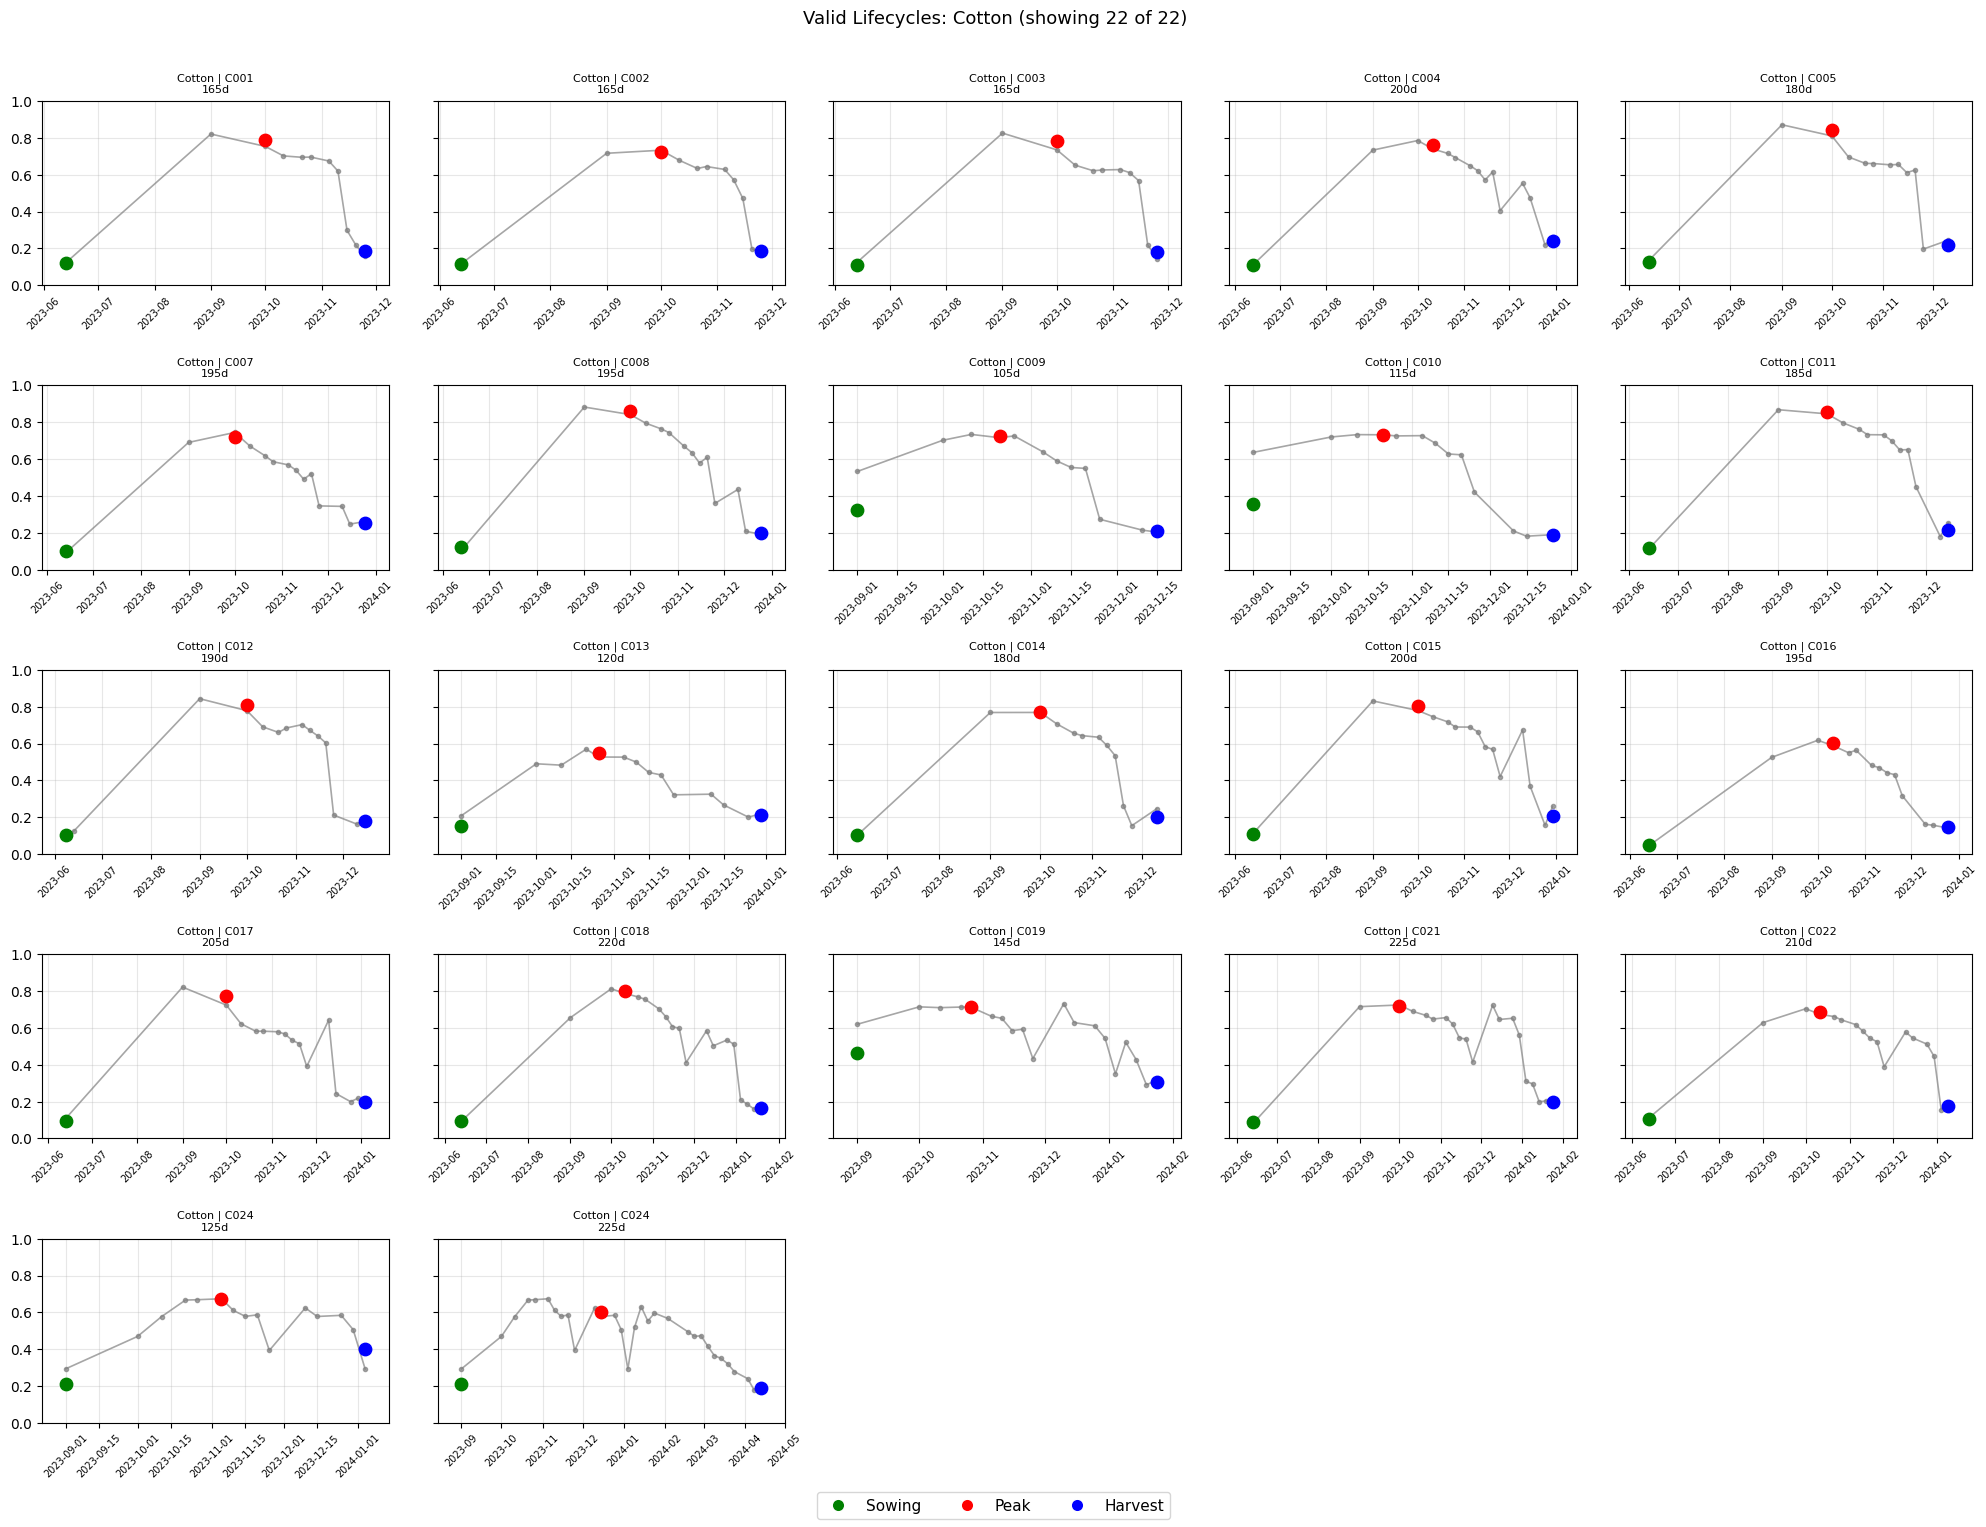

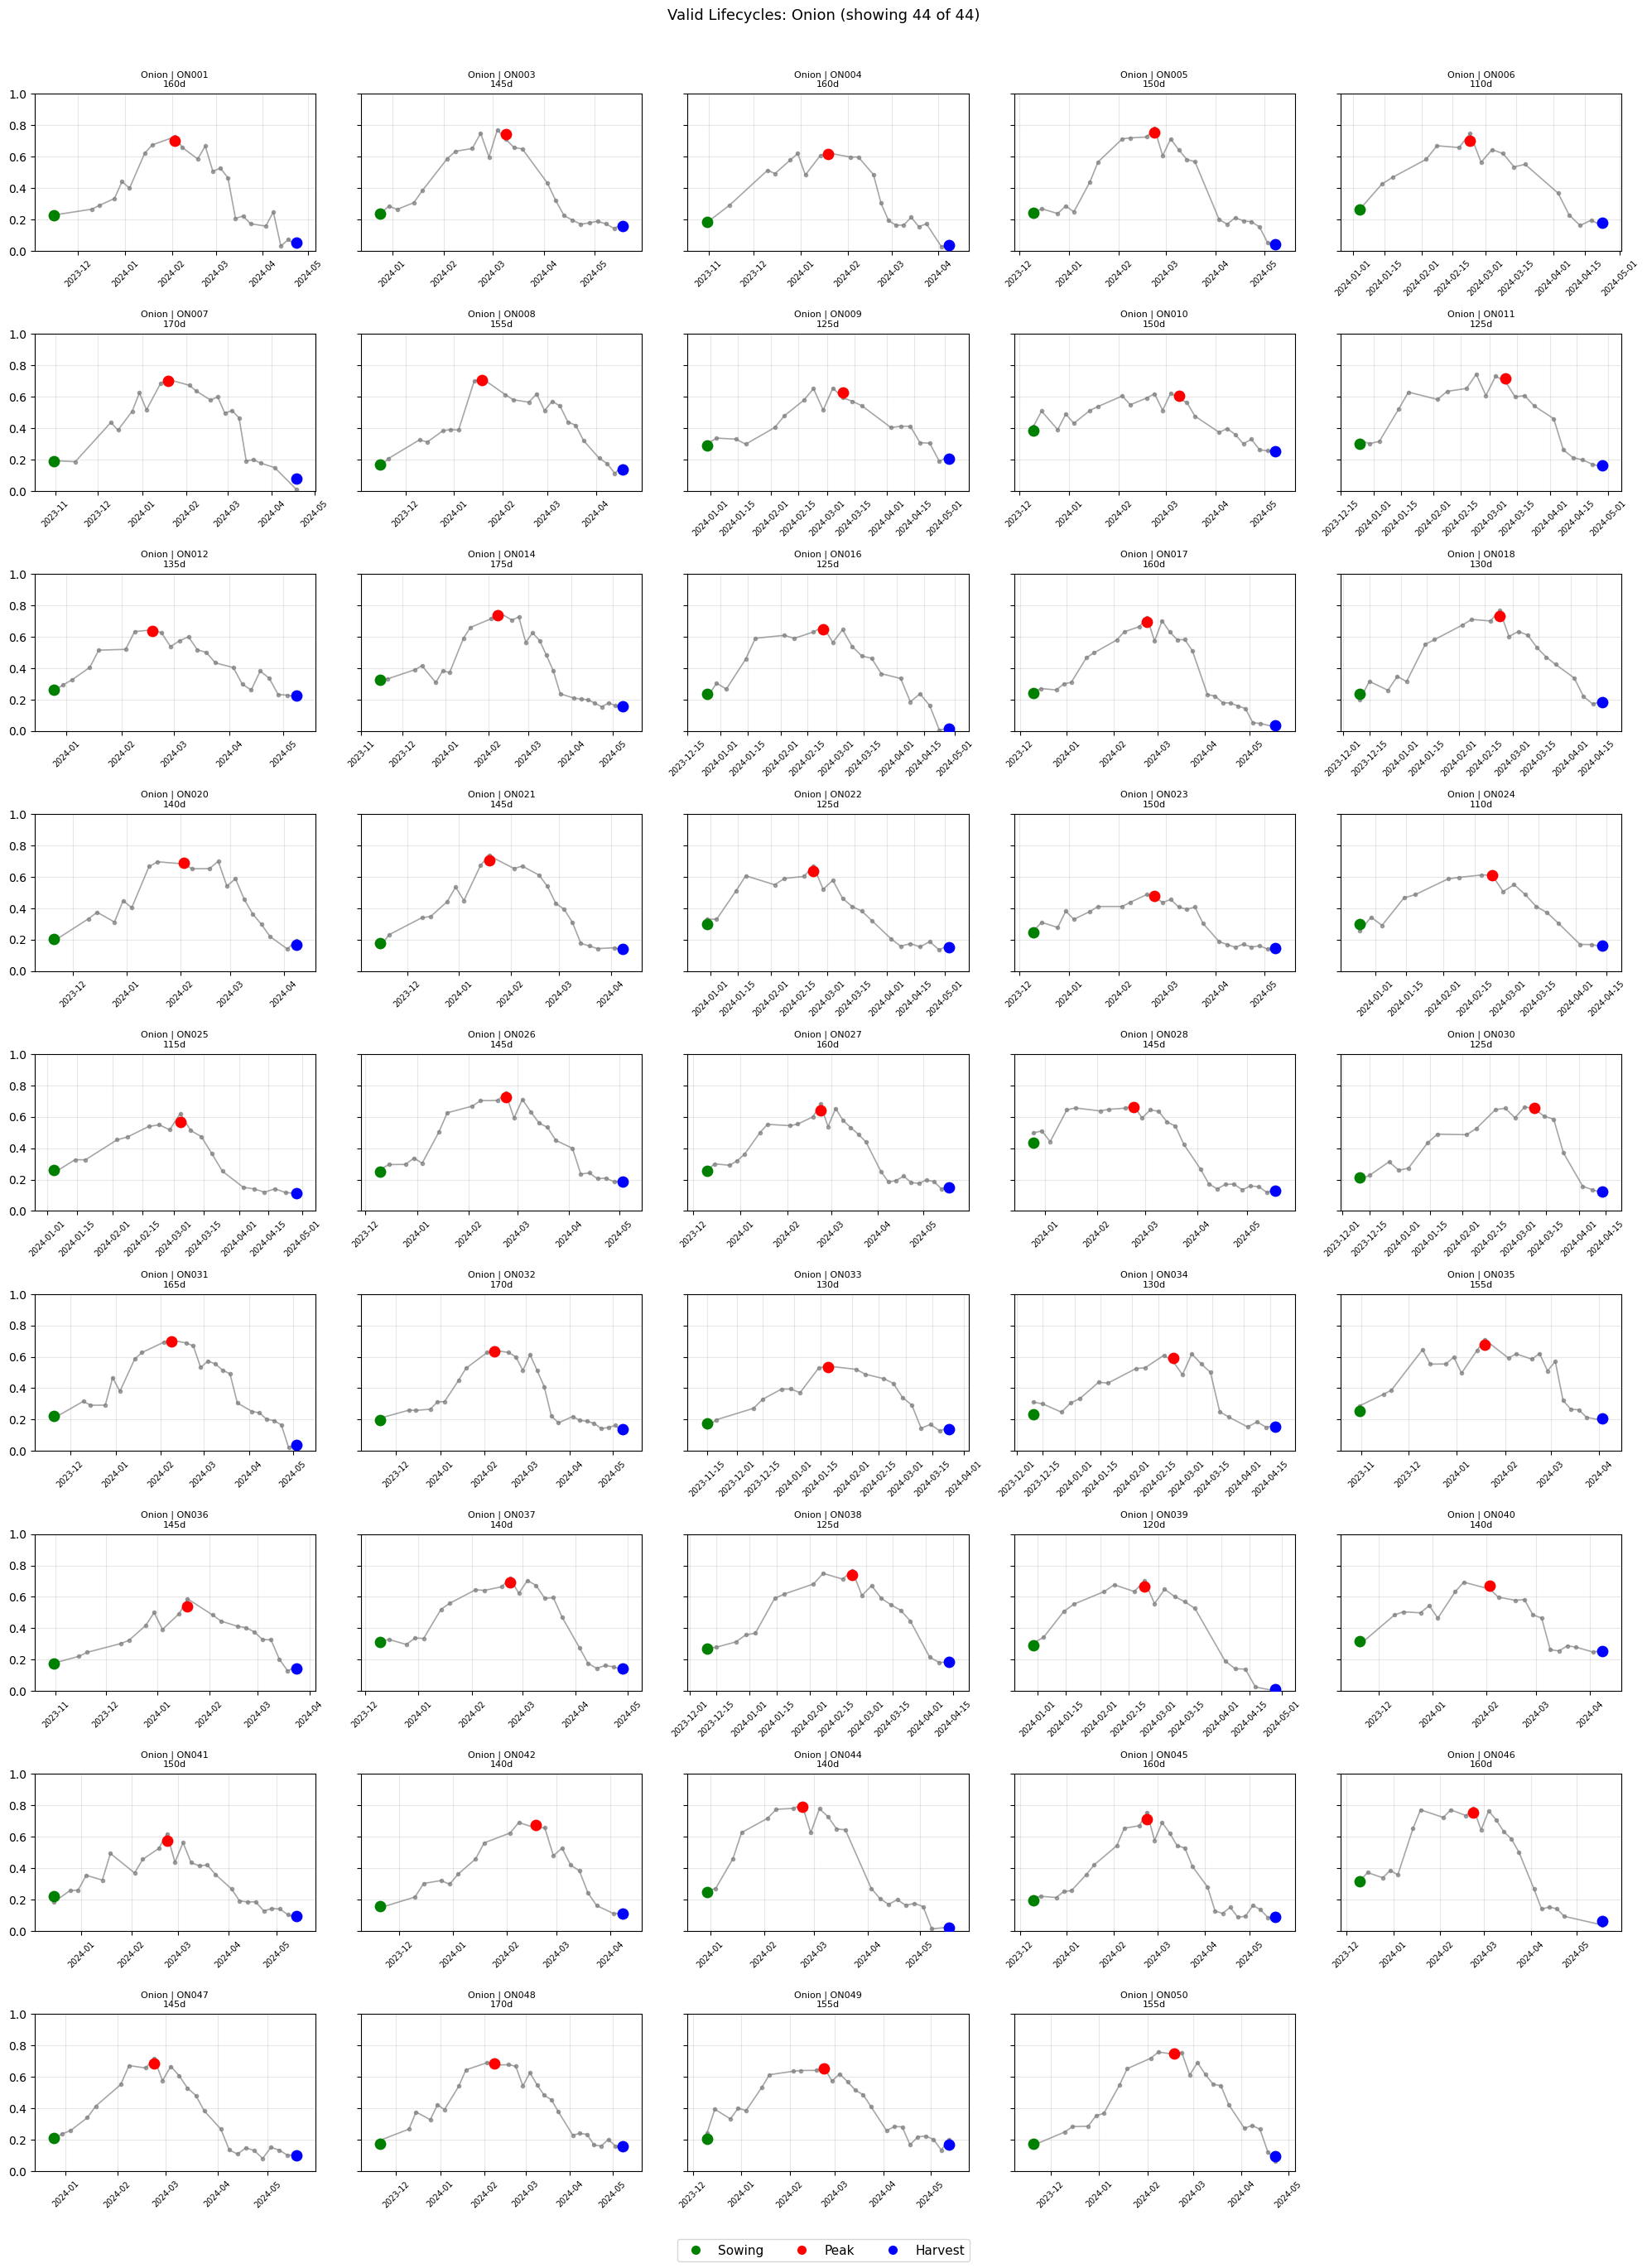

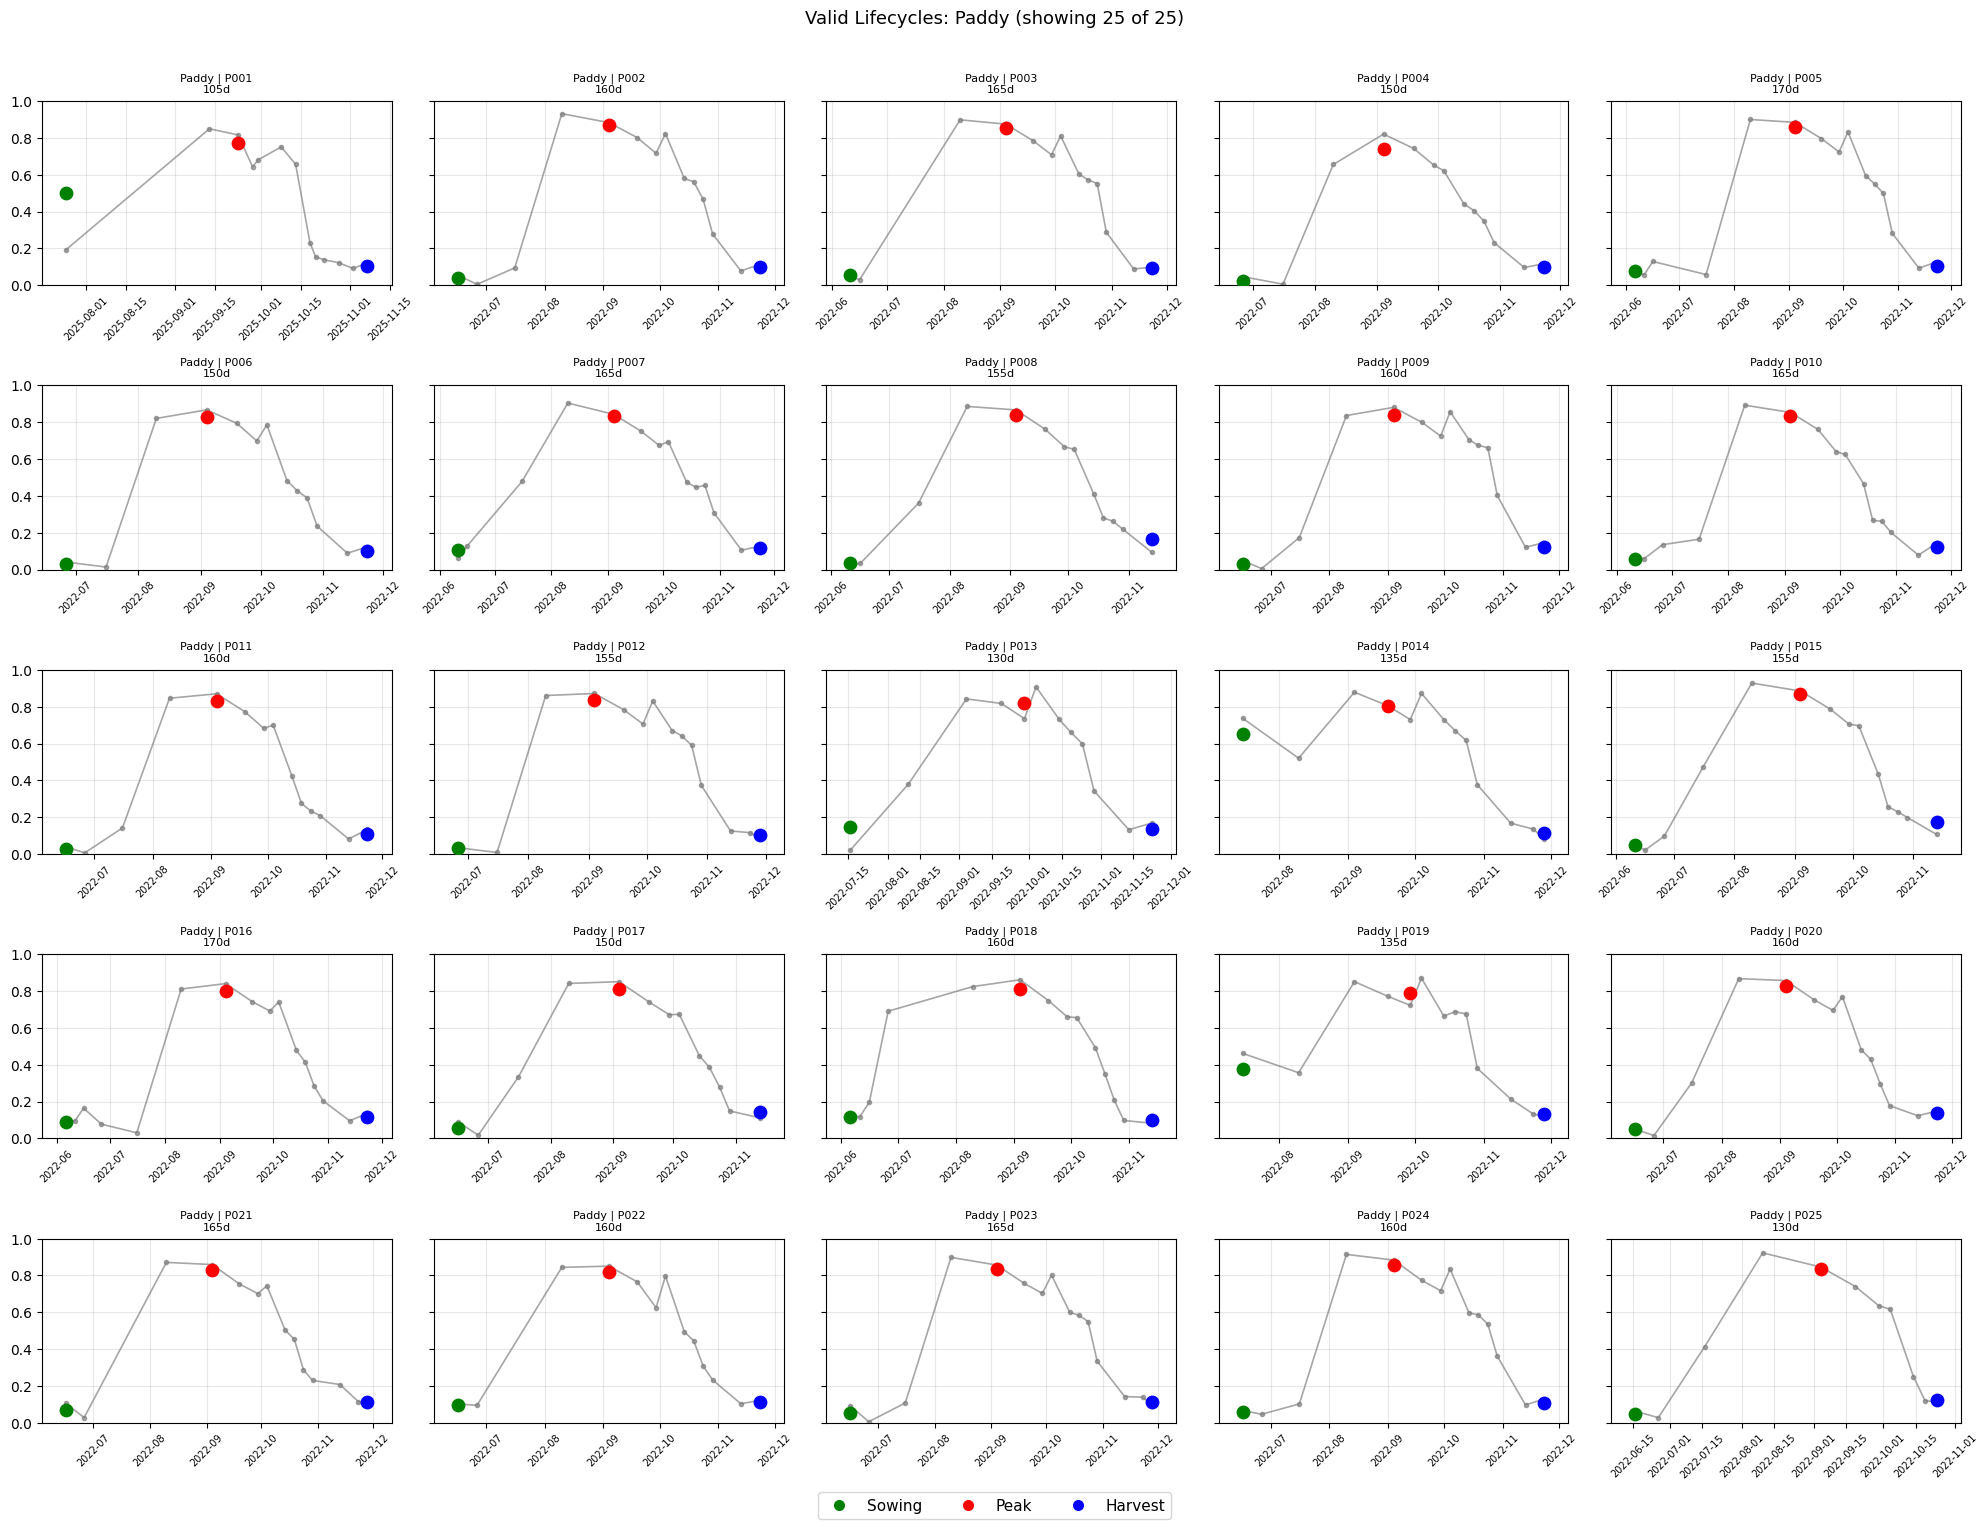

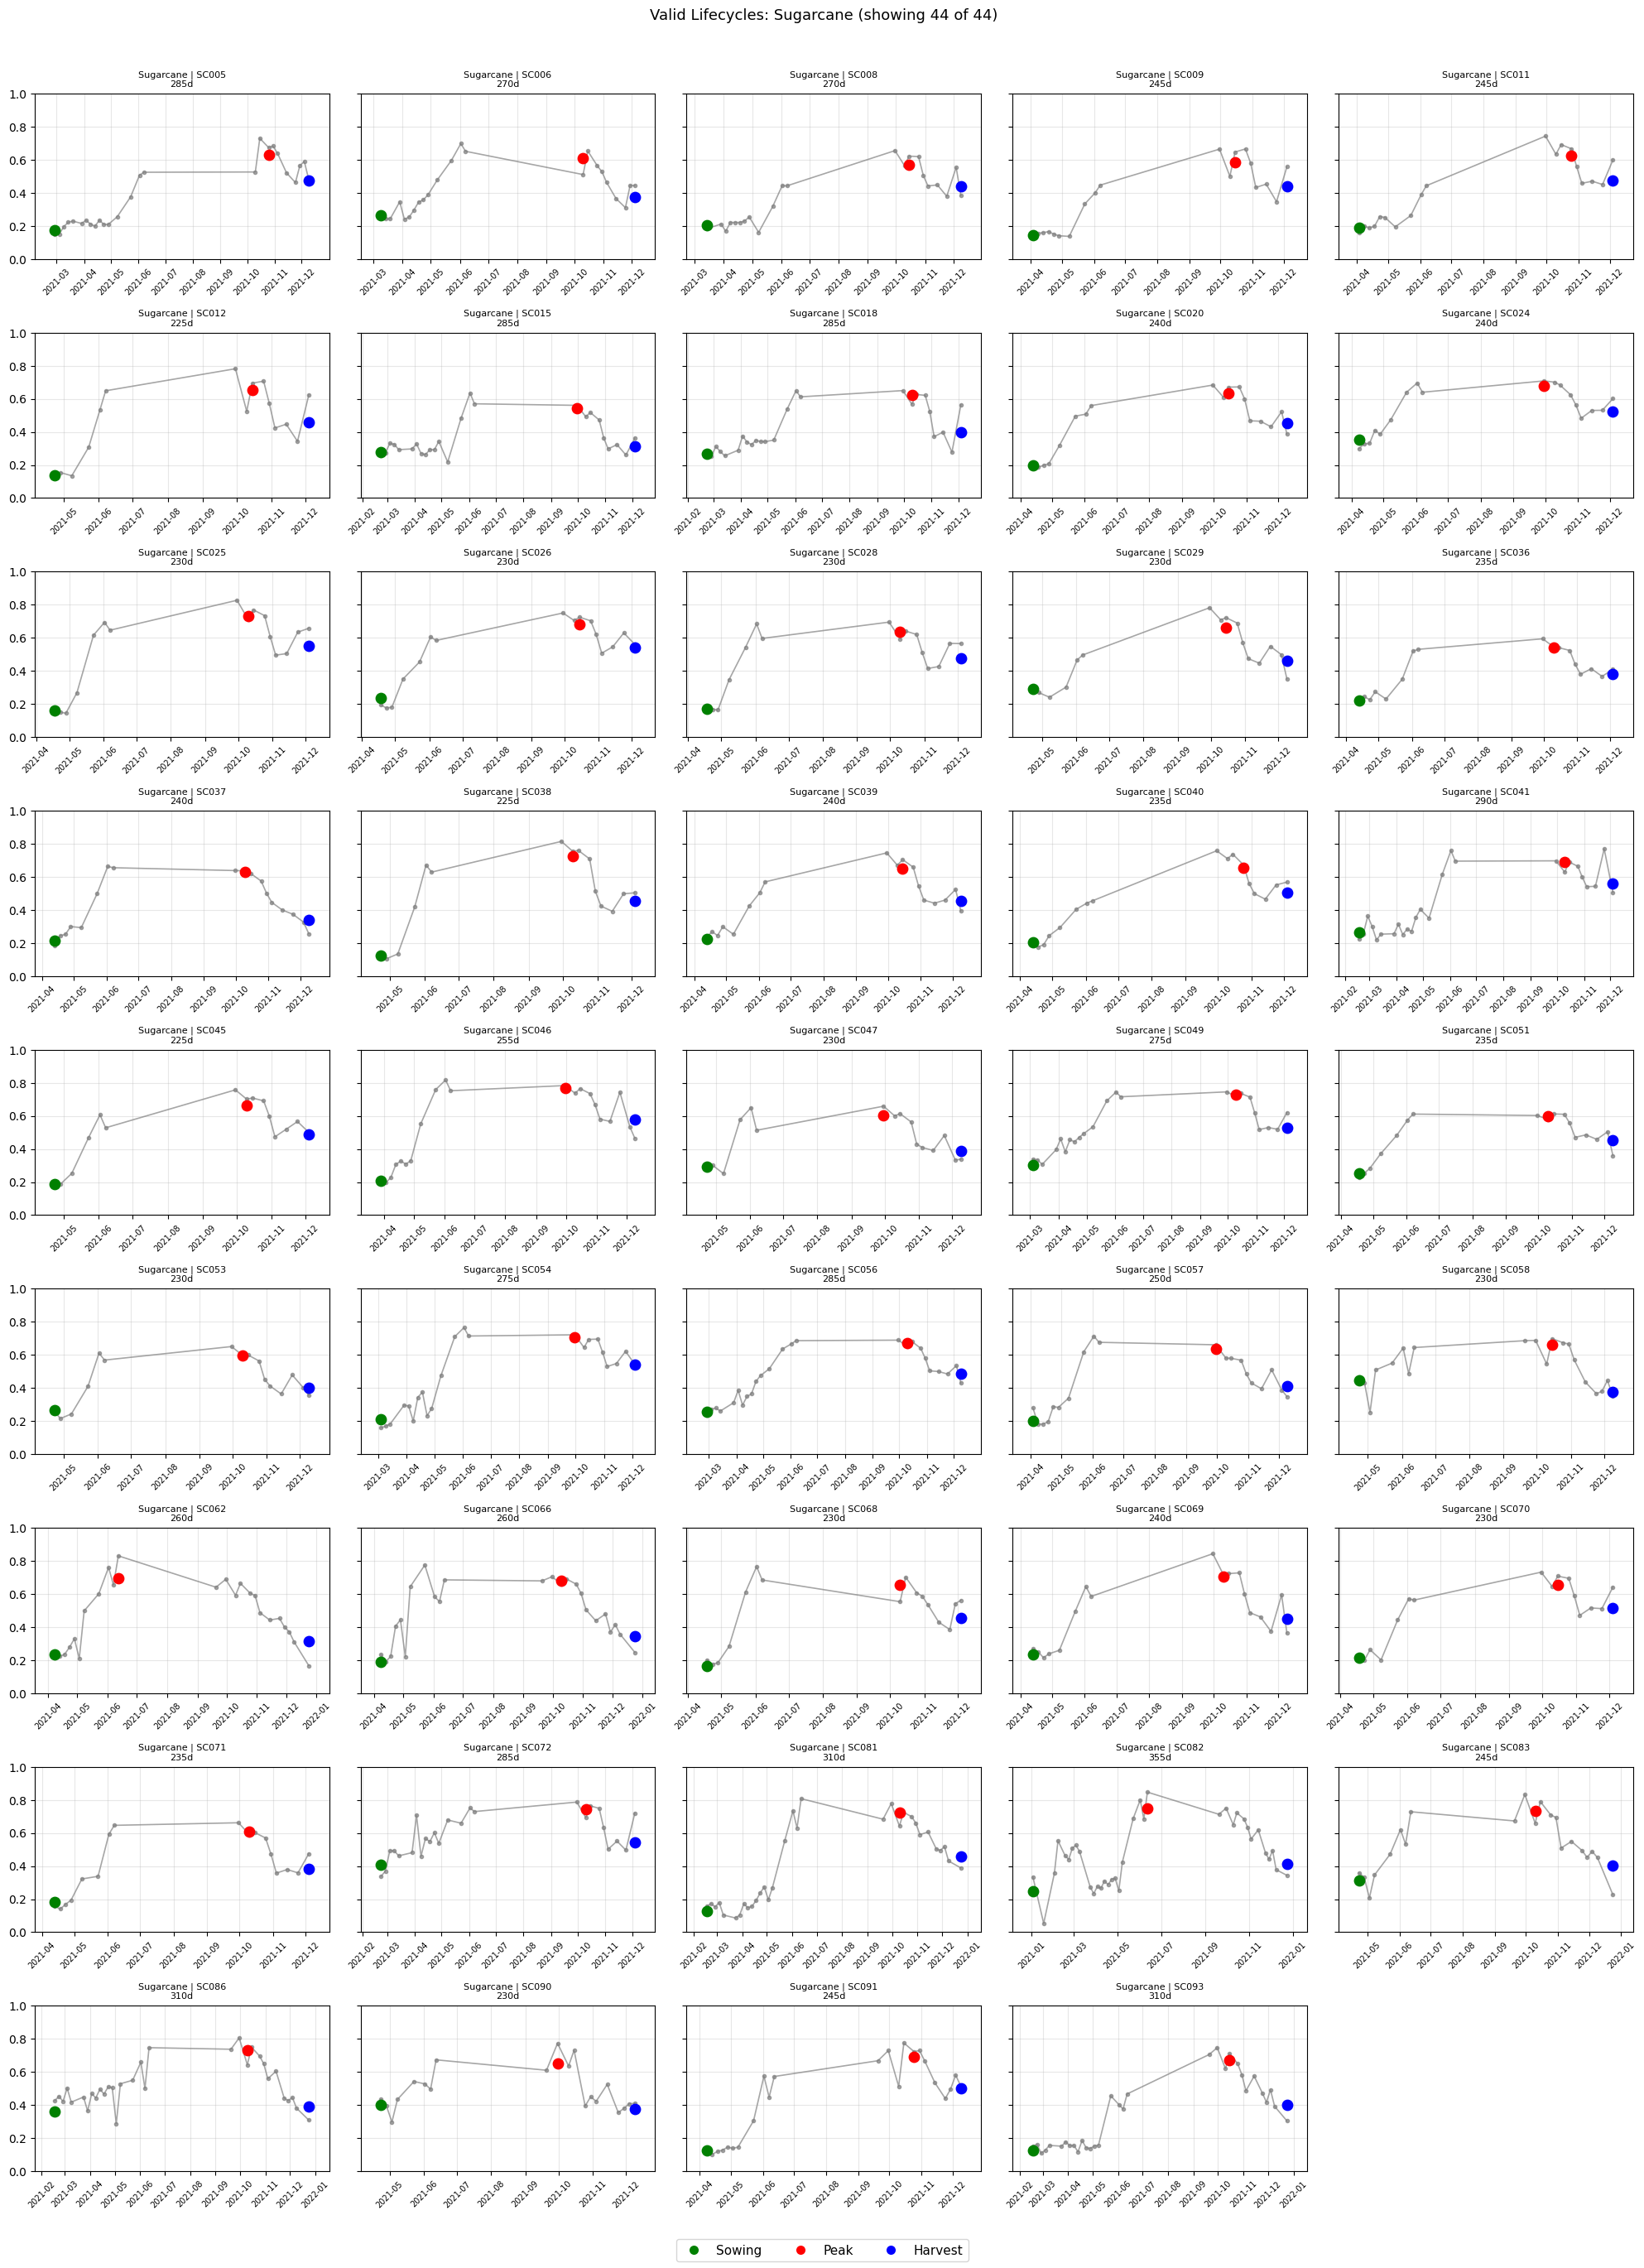

In [ ]:
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=9, label='Sowing'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',   markersize=9, label='Peak'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',  markersize=9, label='Harvest'),
]

def plot_lifecycle_pages(plot_df, suptitle_prefix, ncols=5, max_per_page=20, show_reason=False):
    """Plot every row of plot_df, grouped by Crop, paginated so nothing is cut off / squished."""
    if len(plot_df) == 0:
        print(f'{suptitle_prefix}: nothing to plot (0 rows)')
        return

    for crop in sorted(plot_df['Crop'].unique()):
        crop_df = plot_df[plot_df['Crop'] == crop].reset_index(drop=True)
        n_total = len(crop_df)
        n_pages = int(np.ceil(n_total / max_per_page))

        for page in range(n_pages):
            page_df = crop_df.iloc[page * max_per_page: (page + 1) * max_per_page].reset_index(drop=True)
            nrows = int(np.ceil(len(page_df) / ncols))

            fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True, squeeze=False)
            axes = axes.flatten()

            i = -1
            for i, row in page_df.iterrows():
                ax = axes[i]
                farm_data = ndvi_df[
                    (ndvi_df['Crop'] == row['Crop']) & (ndvi_df['Farm'] == row['Farm']) &
                    (ndvi_df['Date'] >= row['Sowing_Date']) & (ndvi_df['Date'] <= row['Harvest_Date'])
                ].sort_values('Date')
                ax.plot(farm_data['Date'], farm_data['NDVI'], '-o', linewidth=1.2, markersize=3, color='gray', alpha=0.7)
                ax.scatter(row['Sowing_Date'],  row['Sowing_NDVI'],  color='green', s=80, zorder=5)
                ax.scatter(row['Peak_Date'],    row['Peak_NDVI'],    color='red',   s=80, zorder=5)
                ax.scatter(row['Harvest_Date'], row['Harvest_NDVI'], color='blue',  s=80, zorder=5)
                title = f"{row['Crop']} | {row['Farm']}\n{row['Duration_Days']}d"
                if show_reason:
                    title += f"\n{row['Validation']}"
                ax.set_title(title, fontsize=7 if show_reason else 8)
                ax.set_ylim(0, 1)
                ax.tick_params(axis='x', rotation=45, labelsize=7)
                ax.grid(True, alpha=0.3)
                ax.margins(x=0.08)

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])

            fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=11)
            page_note = f' — page {page + 1}/{n_pages}' if n_pages > 1 else ''
            plt.suptitle(f'{suptitle_prefix}: {crop} (showing {len(page_df)} of {n_total}){page_note}', fontsize=13, y=1.01)
            plt.tight_layout(rect=[0, 0.02, 1, 1])
            plt.show()

plot_lifecycle_pages(valid_df, 'Valid Lifecycles', show_reason=False, max_per_page=999)

## 10. Plot Invalid Lifecycles (for inspection)


Total invalid cycles: 47
Crop
Cotton       24
Onion         6
Paddy         2
Sugarcane    15
Name: invalid_cycles, dtype: int64



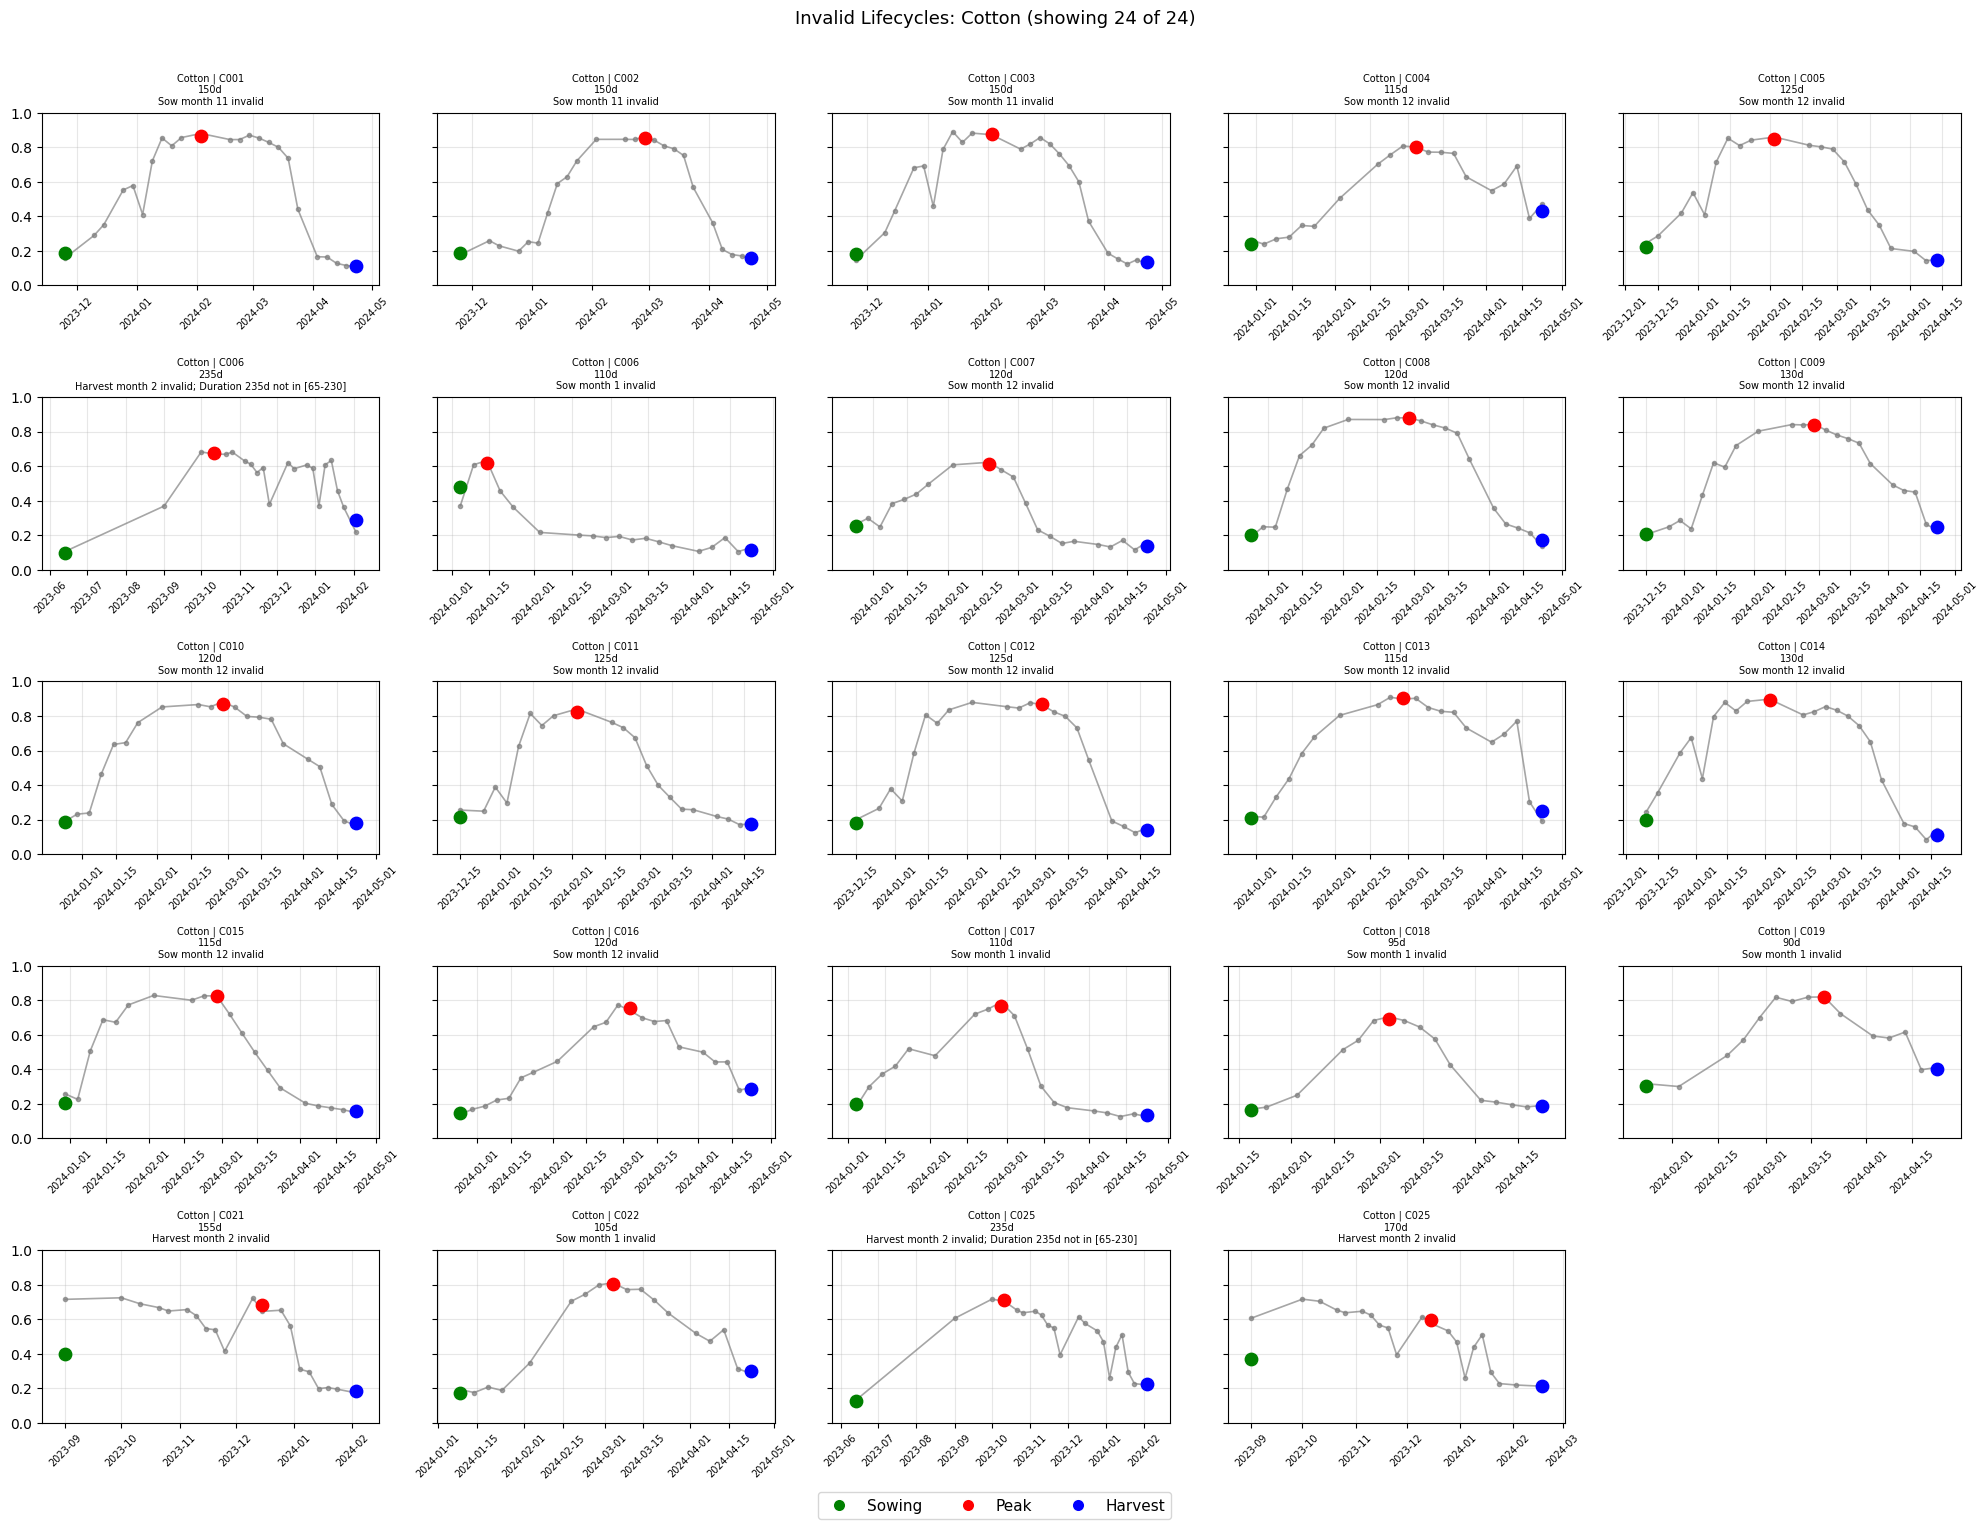

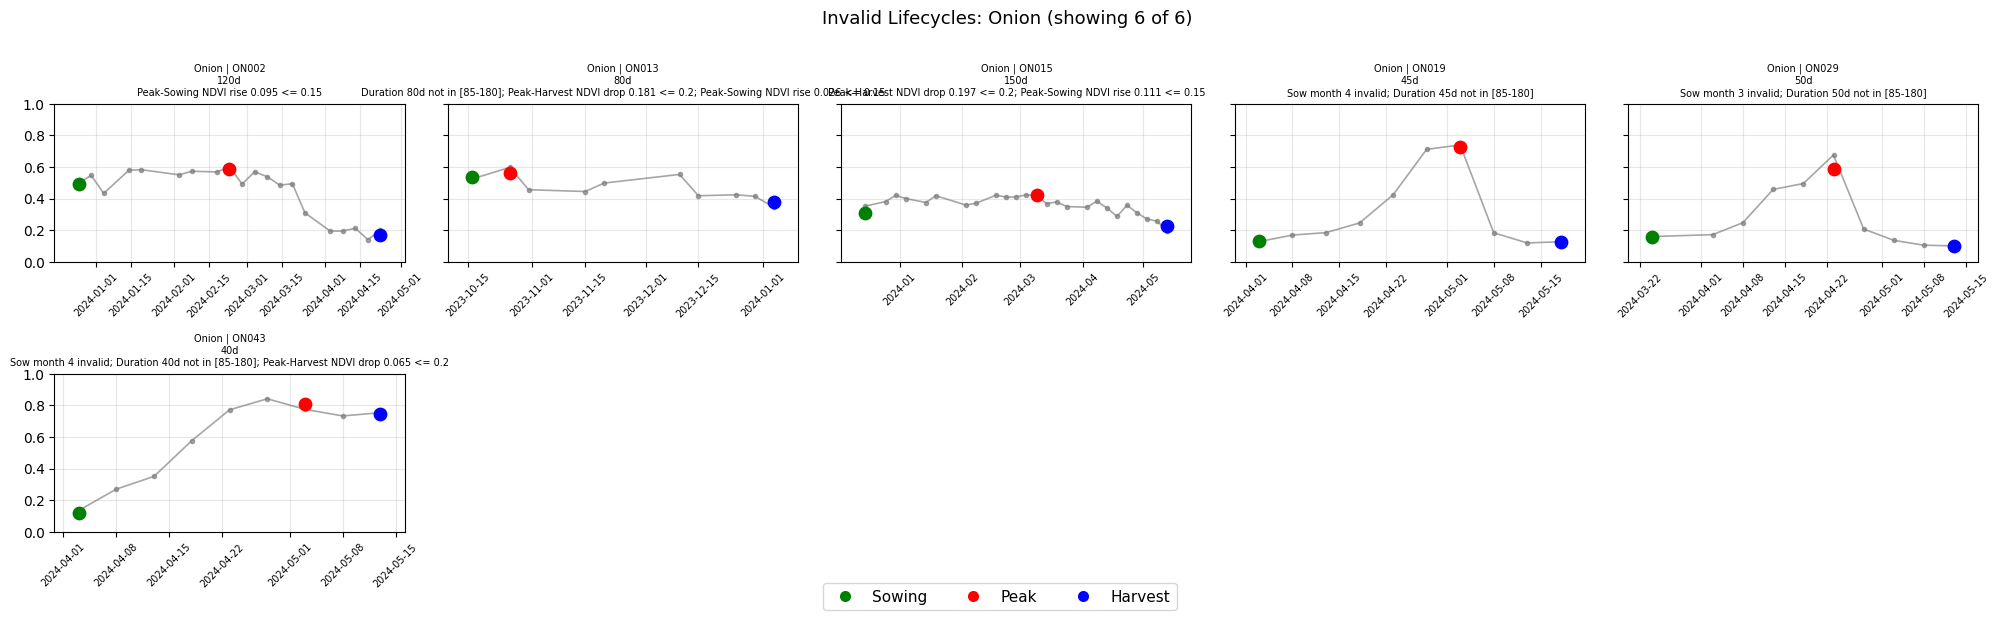

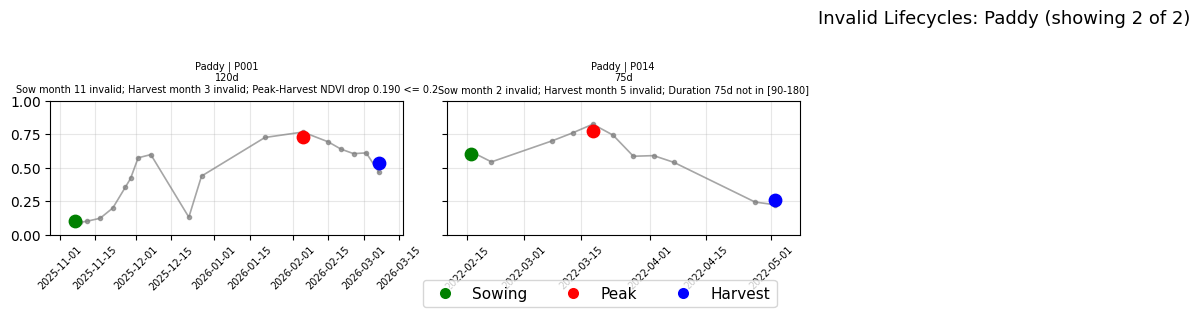

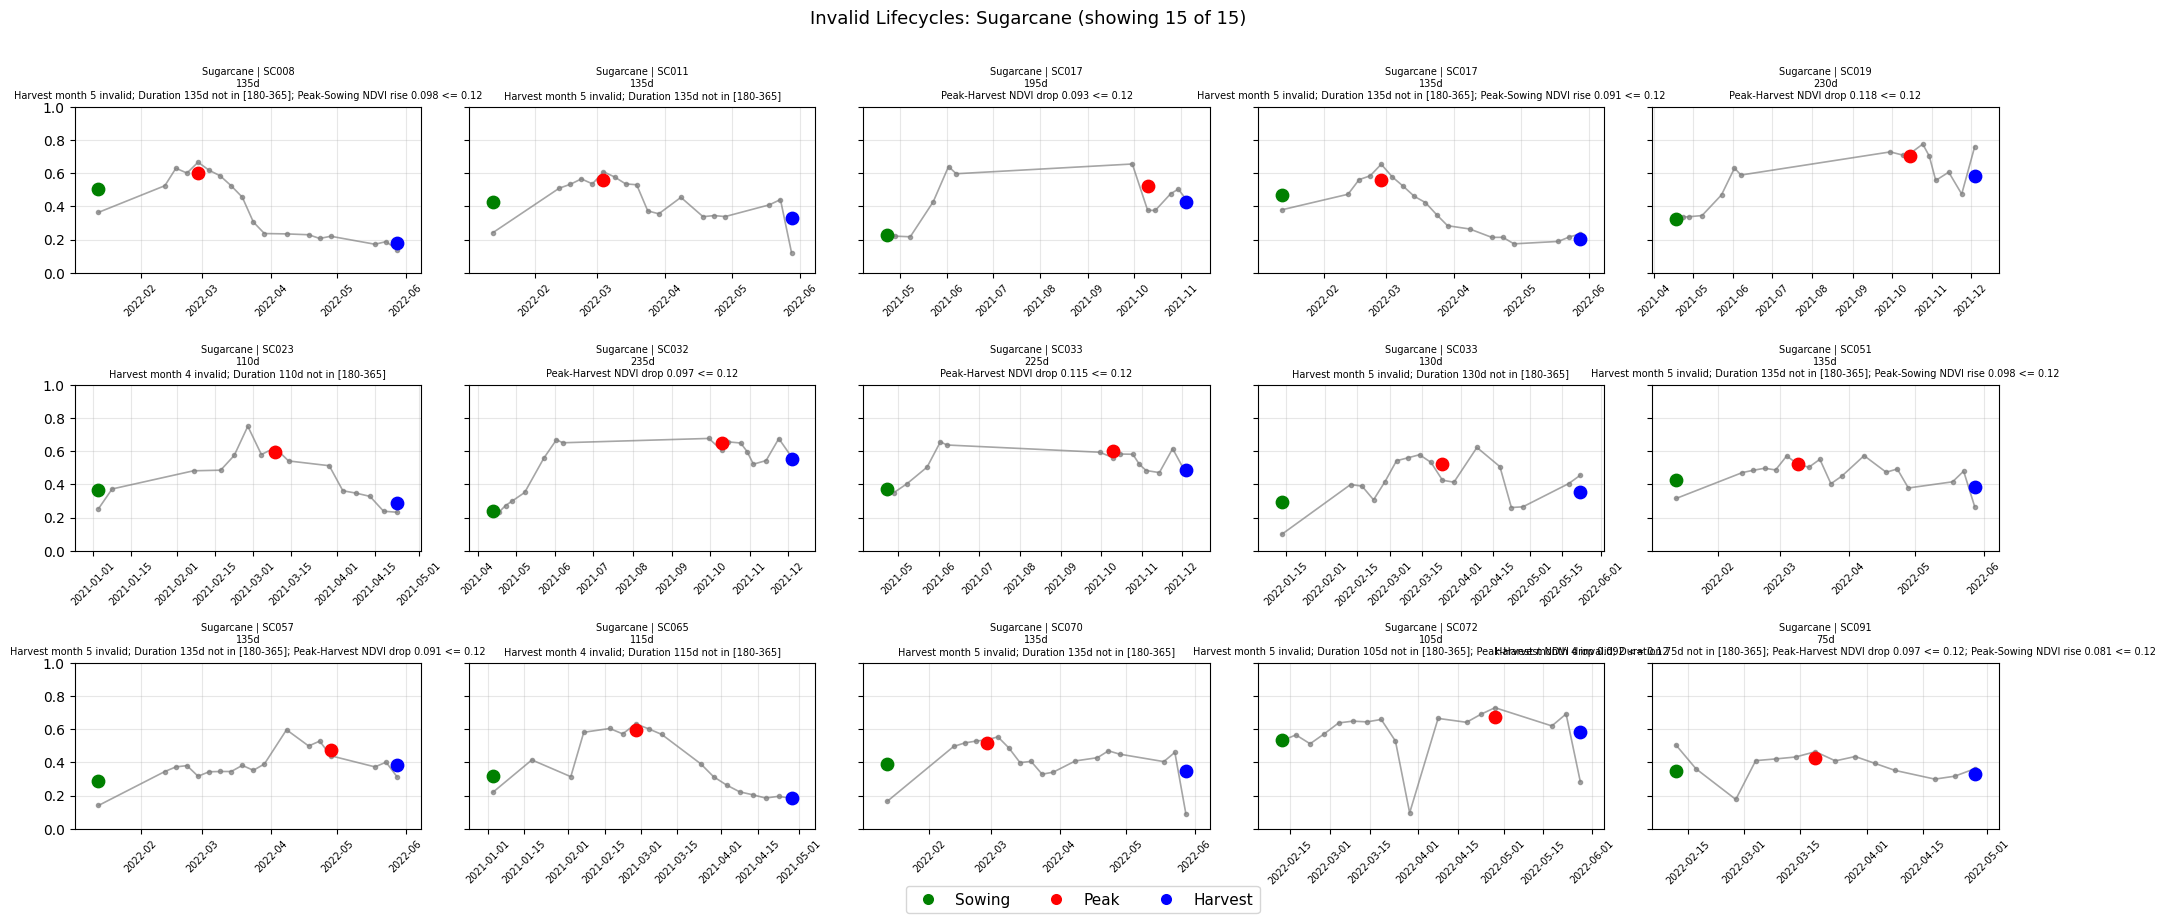

In [ ]:
invalid_plot_df = lifecycle_df[~lifecycle_df['Is_Valid']].reset_index(drop=True)
print(f'Total invalid cycles: {len(invalid_plot_df)}')
print(invalid_plot_df.groupby('Crop').size().rename('invalid_cycles'))
print()

plot_lifecycle_pages(invalid_plot_df, 'Invalid Lifecycles', show_reason=True, max_per_page=999)


## 11. Feature Extraction

In [ ]:
feature_records = []

for _, row in valid_df.iterrows():
    farm_data = ndvi_df[
        (ndvi_df['Crop'] == row['Crop']) & (ndvi_df['Farm'] == row['Farm']) &
        (ndvi_df['Date'] >= row['Sowing_Date']) & (ndvi_df['Date'] <= row['Harvest_Date'])
    ].sort_values('Date')

    ndvi_vals = farm_data['NDVI'].values
    if len(ndvi_vals) < 3:
        continue

    feature_records.append({
        'Crop':           row['Crop'],
        'Farm':           row['Farm'],
        'Duration_Days':  row['Duration_Days'],
        'Peak_NDVI':      row['Peak_NDVI'],
        'Peak_Month':     row['Peak_Month'],
        'Sowing_NDVI':    row['Sowing_NDVI'],
        'Sowing_Month':   row['Sowing_Month'],
        'Harvest_NDVI':   row['Harvest_NDVI'],
        'Harvest_Month':  row['Harvest_Month'],
        'AUC':            row['AUC'],
        'Mean_NDVI':      row['Mean_NDVI'],
        'Std_NDVI':       round(float(np.std(ndvi_vals)), 4),
        'NDVI_range':     round(float(np.ptp(ndvi_vals)), 4),
        'Rise_rate':      round((row['Peak_NDVI'] - row['Sowing_NDVI']) / max((row['Peak_Date'] - row['Sowing_Date']).days, 1), 5),
        'Fall_rate':      round((row['Peak_NDVI'] - row['Harvest_NDVI']) / max((row['Harvest_Date'] - row['Peak_Date']).days, 1), 5),
    })

features_df = pd.DataFrame(feature_records)
features_df.to_excel('lifecycle_features.xlsx', index=False)
print(f'Feature matrix: {features_df.shape}')
print(features_df.groupby('Crop').size().rename('samples'))


Feature matrix: (135, 15)
Crop
Cotton       22
Onion        44
Paddy        25
Sugarcane    44
Name: samples, dtype: int64


Classifying 4 crops: ['Cotton', 'Onion', 'Paddy', 'Sugarcane']
Total valid samples: 135
Crop
Cotton       22
Onion        44
Paddy        25
Sugarcane    44
Name: n_samples, dtype: int64

── Farm-level split (no data leakage) ──
  Train : 93 samples  (4 crops, 93 farms)
  Val   : 21 samples  (4 crops, 20 farms)
  Test  : 21 samples  (4 crops, 21 farms)
  Leaky farms: 0  ← should be 0

Saved: split_train.xlsx  |  split_val.xlsx  |  split_test.xlsx

──  Validation Report  ──
              precision    recall  f1-score   support

      Cotton       1.00      1.00      1.00         4
       Onion       1.00      1.00      1.00         7
       Paddy       1.00      1.00      1.00         4
   Sugarcane       1.00      1.00      1.00         6

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


──  Test Report  (final — touch only once)  ──
              precision    recall  f1-s

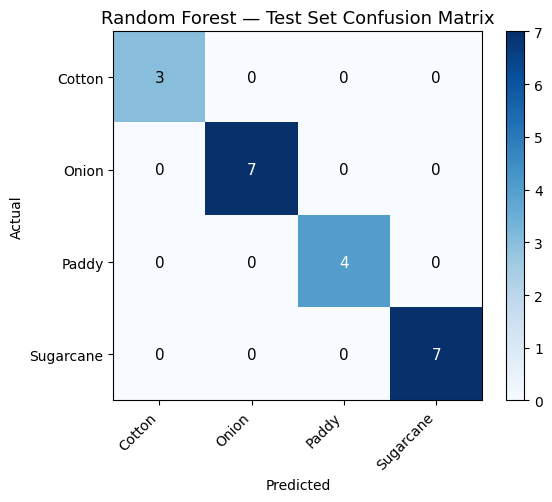

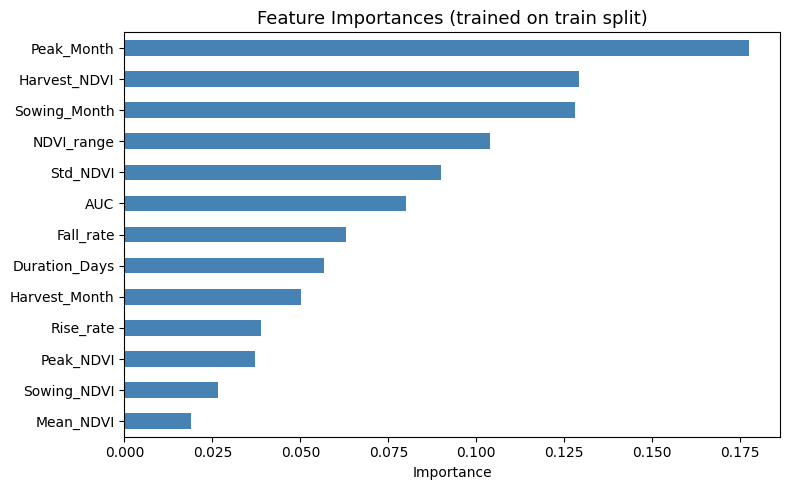

In [ ]:
n_crops = features_df['Crop'].nunique()
print(f'Classifying {n_crops} crops: {sorted(features_df["Crop"].unique())}')

FEATURE_COLS = [
    'Duration_Days', 'Peak_NDVI', 'Peak_Month',
    'Sowing_NDVI',   'Sowing_Month',
    'Harvest_NDVI',  'Harvest_Month',
    'AUC', 'Mean_NDVI', 'Std_NDVI', 'NDVI_range',
    'Rise_rate', 'Fall_rate',
]

ml_df = features_df.dropna(subset=FEATURE_COLS + ['Crop']).reset_index(drop=True)
print(f'Total valid samples: {len(ml_df)}')
print(ml_df.groupby('Crop').size().rename('n_samples'))


farm_crop = ml_df[['Farm', 'Crop']].drop_duplicates().reset_index(drop=True)
farms_arr = farm_crop['Farm'].values
crops_arr = farm_crop['Crop'].values


sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(sss1.split(farms_arr, crops_arr))

farms_train_val = farms_arr[train_val_idx]
crops_train_val = crops_arr[train_val_idx]
farms_test      = farms_arr[test_idx]


sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
train_idx2, val_idx2 = next(sss2.split(farms_train_val, crops_train_val))

farms_train = set(farms_train_val[train_idx2])
farms_val   = set(farms_train_val[val_idx2])
farms_test  = set(farms_test)

def assign_split(farm):
    if farm in farms_train: return 'train'
    if farm in farms_val:   return 'val'
    return 'test'

ml_df['split'] = ml_df['Farm'].apply(assign_split)

train_df   = ml_df[ml_df['split'] == 'train'].reset_index(drop=True)
val_df_ml  = ml_df[ml_df['split'] == 'val'].reset_index(drop=True)
test_df_ml = ml_df[ml_df['split'] == 'test'].reset_index(drop=True)

print(f'\n── Farm-level split (no data leakage) ──')
print(f'  Train : {len(train_df)} samples  ({train_df["Crop"].nunique()} crops, {len(farms_train)} farms)')
print(f'  Val   : {len(val_df_ml)} samples  ({val_df_ml["Crop"].nunique()} crops, {len(farms_val)} farms)')
print(f'  Test  : {len(test_df_ml)} samples  ({test_df_ml["Crop"].nunique()} crops, {len(farms_test)} farms)')


farm_splits = {}
for _, row in ml_df.iterrows():
    farm_splits.setdefault(row['Farm'], set()).add(row['split'])
leaked = {f: ss for f, ss in farm_splits.items() if len(ss) > 1}
print(f'  Leaky farms: {len(leaked)}  ← should be 0')


train_df.to_excel('split_train.xlsx', index=False)
val_df_ml.to_excel('split_val.xlsx',  index=False)
test_df_ml.to_excel('split_test.xlsx', index=False)
print('\nSaved: split_train.xlsx  |  split_val.xlsx  |  split_test.xlsx')


X_train = train_df[FEATURE_COLS].values
y_train = train_df['Crop'].values

X_val   = val_df_ml[FEATURE_COLS].values
y_val   = val_df_ml['Crop'].values

X_test  = test_df_ml[FEATURE_COLS].values
y_test  = test_df_ml['Crop'].values

clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)


y_val_pred = clf.predict(X_val)
print('\n──  Validation Report  ──')
print(classification_report(y_val, y_val_pred, zero_division=0))


y_test_pred = clf.predict(X_test)
print('\n──  Test Report  (final — touch only once)  ──')
print(classification_report(y_test, y_test_pred, zero_division=0))


labels = sorted(set(y_test) | set(y_test_pred))
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest — Test Set Confusion Matrix', fontsize=13)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=11)
plt.tight_layout()
plt.show()


importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances (trained on train split)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 13. Export All Outputs

In [ ]:
from google.colab import files
import zipfile, os

output_files = [
    'lifecycle_results.xlsx',
    'lifecycle_results_validated.xlsx',
    'lifecycle_results_with_flags.xlsx',
    'lifecycle_features.xlsx',
    'split_train.xlsx',
    'split_val.xlsx',
    'split_test.xlsx',
]

zip_name = 'crop_lifecycle_outputs.zip'
with zipfile.ZipFile(zip_name, 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
        else:
            print(f'  (skipped — not found): {f}')

files.download(zip_name)
print('Done — downloaded', zip_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — downloaded crop_lifecycle_outputs.zip
